In [1]:
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('/content/health_dataset.csv')


In [3]:
df.head()

,record_id,age_group,age,weight,gender,region,smoking_status,exercise_frequency,bmi,blood_pressure,diabetes,hypertension,cholesterol_level,glucose_level,visit_date
0,8505374e-12dd-4635-b135-8ca026be73bd,46-60,56,60,Other,North,Smoker,Never,25.76,120.12,True,False,176.90,84.37,2024-01-01
1,b66c628f-bed8-4087-b5f4-63697ddf1df6,60+,69,105,Male,East,Smoker,Rarely,27.31,135.06,False,True,184.56,79.50,2024-01-02
2,e4536f63-a781-40a2-9b56-5513e2a63f4b,46-60,46,108,Female,West,Non-Smoker,Weekly,32.45,152.81,True,False,216.82,123.67,2024-01-03
3,7abe9ccb-ed52-4524-9c10-a23a1c2f9aeb,26-35,32,107,Male,North,Non-Smoker,Never,20.69,100.64,True,False,225.36,133.48,2024-01-04
4,0217faed-723b-4d77-9628-9facc57f8a79,46-60,60,66,Male,North,Smoker,Daily,23.60,110.27,False,False,232.83,80.30,2024-01-05


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   record_id           500 non-null    object 
 1   age_group           500 non-null    object 
 2   age                 500 non-null    int64  
 3   weight              500 non-null    int64  
 4   gender              500 non-null    object 
 5   region              500 non-null    object 
 6   smoking_status      500 non-null    object 
 7   exercise_frequency  500 non-null    object 
 8   bmi                 500 non-null    float64
 9   blood_pressure      500 non-null    float64
 10  diabetes            500 non-null    bool   
 11  hypertension        500 non-null    bool   
 12  cholesterol_level   500 non-null    float64
 13  glucose_level       500 non-null    float64
 14  visit_date          500 non-null    object 
dtypes: bool(2), float64(4), int64(2), object(7)
memory usage:

In [5]:
df.describe()

,age,weight,bmi,blood_pressure,cholesterol_level,glucose_level
count,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000
mean,44.220000,76.200000,24.952720,119.254060,188.729300,99.882660
std,15.036082,18.990874,3.927583,14.858155,34.386003,20.357806
min,18.000000,45.000000,13.510000,67.930000,94.720000,41.910000
25%,32.000000,60.000000,22.347500,109.002500,165.152500,86.462500
50%,45.000000,76.000000,24.995000,120.130000,189.540000,98.195000
75%,57.000000,93.000000,27.562500,129.885000,210.975000,114.737500
max,69.000000,109.000000,35.920000,159.510000,282.580000,152.750000


In [6]:
df.isnull().sum()

,0
record_id,0
age_group,0
age,0
weight,0
gender,0
region,0
smoking_status,0
exercise_frequency,0
bmi,0
blood_pressure,0


Hypothesis:
H0 = Smoking has no effect on Diabetes
H1 = Smoking affects Diabetes

In [7]:
contingency_table = pd.crosstab(df['smoking_status'], df['diabetes'])

contingency_table

diabetes,False,True
smoking_status,,
Former Smoker,100,46
Non-Smoker,122,56
Smoker,122,54


In [8]:
chi2, p, dof, expected = stats.chi2_contingency(contingency_table)

print("Chi-Square Value:", chi2)
print("P-Value:", p)

Chi-Square Value: 0.03405463254329097
P-Value: 0.9831168291817507


In [9]:
if p < 0.05:
    print("Reject Null Hypothesis (H0)")
    print("Smoking affects diabetes prevalence")
else:
    print("Accept Null Hypothesis (H0)")
    print("Smoking has no significant effect on diabetes prevalence")

Accept Null Hypothesis (H0)
Smoking has no significant effect on diabetes prevalence


In [10]:
mean_age = np.mean(df['age'])

std_age = np.std(df['age'], ddof=1)

n = len(df['age'])

confidence_interval = stats.t.interval(
    0.95,
    df=n-1,
    loc=mean_age,
    scale=std_age/np.sqrt(n)
)

print("95% Confidence Interval:", confidence_interval)

95% Confidence Interval: (np.float64(42.898849082611875), np.float64(45.54115091738812))


In [11]:
male_bmi = df[df['gender'] == 'Male']['bmi']

female_bmi = df[df['gender'] == 'Female']['bmi']

t_stat, p_value = stats.ttest_ind(male_bmi, female_bmi)

print("T-Statistic:", t_stat)
print("P-Value:", p_value)

T-Statistic: 0.05643232293712057
P-Value: 0.9550312525701018


In [12]:
if p_value < 0.05:
    print("Significant Difference Between Male and Female BMI")
else:
    print("No Significant Difference Between Male and Female BMI")

No Significant Difference Between Male and Female BMI


In [13]:
groups = [
    df[df['age_group'] == grp]['blood_pressure']
    for grp in df['age_group'].unique()
]

f_stat, p_val = stats.f_oneway(*groups)

print("F-Statistic:", f_stat)
print("P-Value:", p_val)

F-Statistic: 0.7853486093445636
P-Value: 0.5350379583534643


In [14]:
if p_val < 0.05:
    print("Age groups significantly differ in blood pressure")
else:
    print("No significant difference among age groups")

No significant difference among age groups


In [15]:
correlation = df['age'].corr(df['bmi'])

print("Correlation:", correlation)

Correlation: -0.05805450604361573


In [16]:
covariance = df['age'].cov(df['bmi'])

print("Covariance:", covariance)

Covariance: -3.4284352705410805


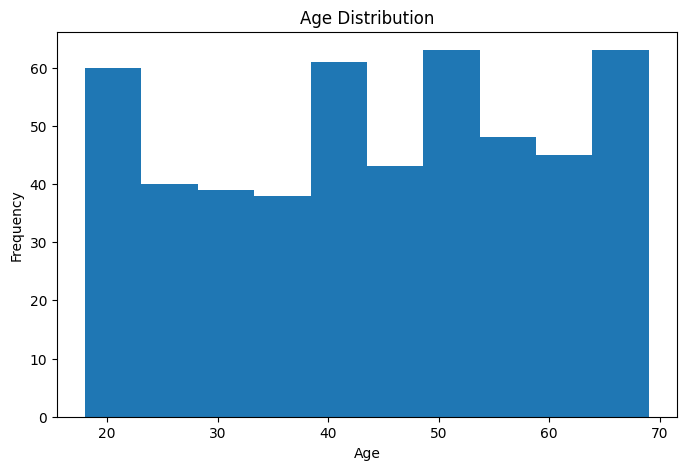

In [17]:
plt.figure(figsize=(8,5))

plt.hist(df['age'], bins=10)

plt.title("Age Distribution")

plt.xlabel("Age")

plt.ylabel("Frequency")

plt.show()

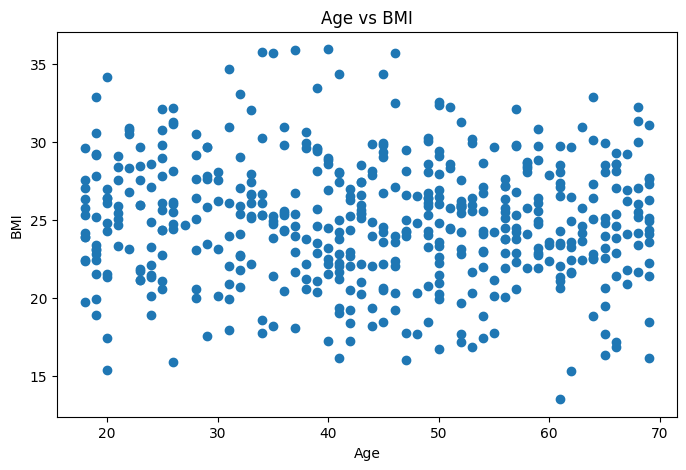

In [20]:
plt.figure(figsize=(8,5))

plt.scatter(df['age'], df['bmi'])

plt.title("Age vs BMI")

plt.xlabel("Age")

plt.ylabel("BMI")

plt.show()

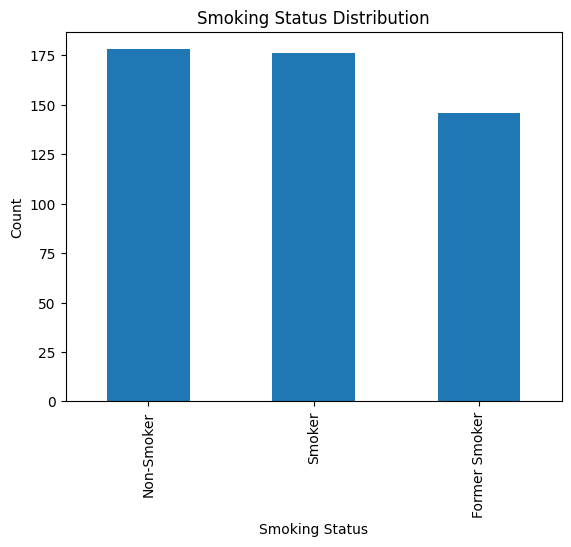

In [22]:
df['smoking_status'].value_counts().plot(kind='bar')

plt.title("Smoking Status Distribution")

plt.xlabel("Smoking Status")

plt.ylabel("Count")

plt.show()

In [23]:
print("Project Completed Successfully")
print("Inferential Statistics Applied on Health Dataset")

Project Completed Successfully
Inferential Statistics Applied on Health Dataset
